# Weeks 1-2: Understanding the solar reflection formalism

# Weeks 3-5: Reproduction of the results from the main reference paper

## Differential flux

In [1]:
# Imports, plotting style, constants

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1

trapz = np.trapz

plt.rcParams.update({
    "figure.figsize": (7.0, 4.8),
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# Unit conversions and constants
ALPHA_EM = 1.0 / 137.035999084
GEV2_TO_CM2 = 0.389379e-27
KEV_PER_GEV = 1.0e6

C_CM_S = 2.99792458e10
AU_CM  = 1.495978707e13

# Solar one-zone benchmark inputs
T_SUN_KEV     = 1.1
N_E_CORE_CM3  = 2.0e25
V_CORE_CM3    = 2.2e31
RHO0_GEV_CM3  = 0.30
VESC_OVER_V0  = 7.0

# Electron mass
M_E_KEV = 510.99895

# XENON1T constants
A_XE_GMOL  = 131.293
ZFREE_XE   = 26
N_AVO      = 6.02214076e23
SEC_PER_YR = 365.25 * 24.0 * 3600.0
NT_PER_TON = (N_AVO * ZFREE_XE / A_XE_GMOL) * 1.0e6

# Resolution model
A_RES = 0.313
B_RES = 0.0017

def sigma_res_keV(E_keV, a=A_RES, b=B_RES):
    E = np.maximum(np.asarray(E_keV, float), 0.0)
    return a * np.sqrt(E) + b * E

In [2]:
# One-zone solar iDM flux helpers

def mu_keV(mchi_GeV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return (mchi_keV * M_E_KEV) / (mchi_keV + M_E_KEV)

def thermal_eps_line(mchi_GeV, alpha_D=0.5, r=3.0):
    """
    Analytic thermal-target estimate from Eq. (3.6).
    r = mA'/mchi
    """
    return 1.0e-4 * (mchi_GeV / 0.1) * (r / 3.0)**2 * (alpha_D / 0.5)**(-0.5)

def sigma_e_contact_cm2(mchi_GeV, alpha_D=0.5, r=3.0):
    """
    Electron cross section from Eq. (2.3) in the contact limit.
    """
    me_GeV = M_E_KEV * 1e-6
    mu_GeV = (mchi_GeV * me_GeV) / (mchi_GeV + me_GeV)

    eps = thermal_eps_line(mchi_GeV, alpha_D=alpha_D, r=r)
    y   = (eps**2) * alpha_D / (r**4)

    sigma_GeV_m2 = 16.0 * np.pi * ALPHA_EM * mu_GeV**2 * y / (mchi_GeV**4)
    return sigma_GeV_m2 * GEV2_TO_CM2

def vmin_of_K(mchi_GeV, Kstar_keV, delta_keV):
    """
    Eq. (4.6).
    """
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    K        = np.maximum(np.asarray(Kstar_keV, float), 1e-300)

    return ((mchi_keV * K) / mu + delta_keV) / np.sqrt(2.0 * mchi_keV * K)

def vmin2_for_K(mchi_GeV, Kstar_keV, delta_keV):
    vmin = vmin_of_K(mchi_GeV, Kstar_keV, delta_keV)
    return vmin * vmin

def avg_dsigmadK_v_cm3_s_keV(mchi_GeV, delta_keV, Kstar_keV, alpha_D=0.5, r=3.0):
    """
    < (dσ/dK) v > in the one-zone solar core.
    """
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    sigma_e  = sigma_e_contact_cm2(mchi_GeV, alpha_D=alpha_D, r=r)

    pref = sigma_e * C_CM_S * (mchi_keV / (2.0 * mu**2))
    thermal = np.sqrt(2.0 * M_E_KEV / (np.pi * T_SUN_KEV))
    return pref * thermal * np.exp(-(M_E_KEV / (2.0 * T_SUN_KEV)) * vmin2_for_K(mchi_GeV, Kstar_keV, delta_keV))

def dphi_dKstar_solar(mchi_GeV, delta_keV, Kgrid_keV, alpha_D=0.5, r=3.0):
    """
    Eq. (4.2) in the one-zone approximation.
    """
    nchi_inf  = RHO0_GEV_CM3 / mchi_GeV
    nchi_core = nchi_inf * VESC_OVER_V0

    pref = N_E_CORE_CM3 * nchi_core * V_CORE_CM3 / (4.0 * np.pi * AU_CM**2)
    return pref * avg_dsigmadK_v_cm3_s_keV(mchi_GeV, delta_keV, Kgrid_keV, alpha_D=alpha_D, r=r)

def sigma_v_eq48_cm3_s(mchi_GeV, delta_keV, alpha_D=0.5, r=3.0):
    """
    Eq. (4.8), used as a benchmark check.
    """
    mu      = mu_keV(mchi_GeV)
    sigma_e = sigma_e_contact_cm2(mchi_GeV, alpha_D=alpha_D, r=r)
    x = M_E_KEV * delta_keV / (2.0 * mu * T_SUN_KEV)

    pref = sigma_e * C_CM_S * np.sqrt(2.0 * M_E_KEV * delta_keV / (np.pi * T_SUN_KEV * mu))
    return pref * np.exp(-x) * k1(x)

In [3]:
# Benchmark point and Eq. (4.8) check

MCHI_BENCH_MEV = 3.7
DELTA_BENCH_KEV = 3.5
ALPHA_D_BENCH = 0.5
RATIO_MA_MCHI = 3.0

mchi_bench_GeV = 1.0e-3 * MCHI_BENCH_MEV

K_check = np.linspace(1e-4, 10.0, 40000)

sigma_v_from_differential = trapz(
    avg_dsigmadK_v_cm3_s_keV(
        mchi_bench_GeV,
        DELTA_BENCH_KEV,
        K_check,
        alpha_D=ALPHA_D_BENCH,
        r=RATIO_MA_MCHI
    ),
    K_check
)

sigma_v_from_eq48 = sigma_v_eq48_cm3_s(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI
)

print(f"<sigma v> from integrating dσ/dK = {sigma_v_from_differential:.6e} cm^3/s")
print(f"<sigma v> from Eq. (4.8)        = {sigma_v_from_eq48:.6e} cm^3/s")
print(f"relative difference             = {abs(sigma_v_from_differential/sigma_v_from_eq48 - 1):.3e}")

<sigma v> from integrating dσ/dK = 1.536148e-30 cm^3/s
<sigma v> from Eq. (4.8)        = 1.739873e-29 cm^3/s
relative difference             = 9.117e-01


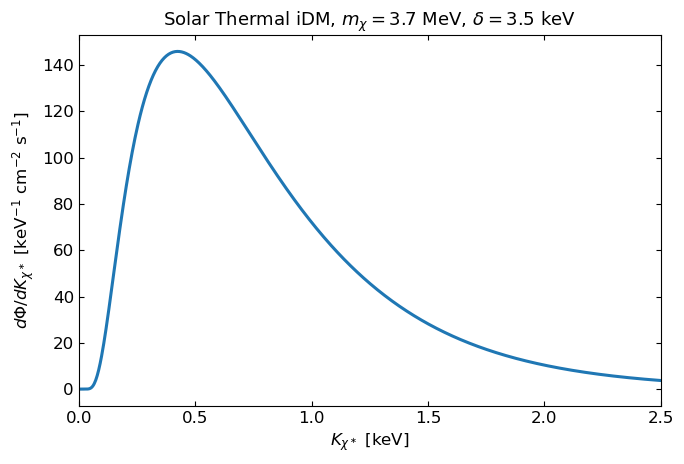

Peak flux = 145.898 keV^-1 cm^-2 s^-1
Peak at K* = 0.423 keV


In [4]:
# Figure 4 reproduction: one-zone differential flux dPhi/dK*

K_FIG4_KEV = np.linspace(1e-3, 2.5, 800)
DPHI_FIG4 = dphi_dKstar_solar(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    K_FIG4_KEV,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI
)

fig, ax = plt.subplots()
ax.plot(K_FIG4_KEV, DPHI_FIG4, lw=2.2)
ax.set_xlim(0.0, 2.5)
ax.set_xlabel(r"$K_{\chi^\ast}\ [{\rm keV}]$")
ax.set_ylabel(r"$d\Phi/dK_{\chi^\ast}\ [{\rm keV}^{-1}\ {\rm cm}^{-2}\ {\rm s}^{-1}]$")
ax.set_title(r"Solar Thermal iDM, $m_\chi = 3.7$ MeV, $\delta = 3.5$ keV")
plt.tight_layout()
plt.show()

print(f"Peak flux = {DPHI_FIG4.max():.3f} keV^-1 cm^-2 s^-1")
print(f"Peak at K* = {K_FIG4_KEV[np.argmax(DPHI_FIG4)]:.3f} keV")

## Event-rate in XENON1T

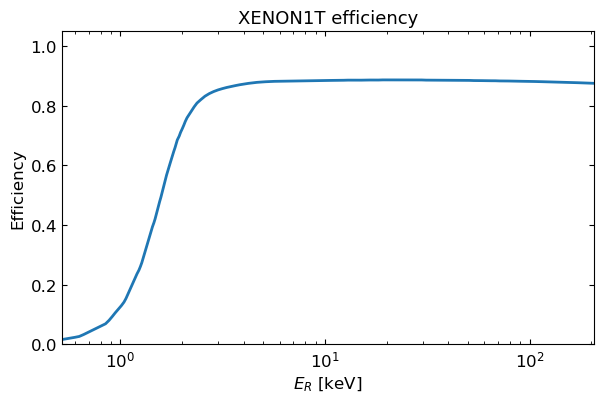

In [5]:
# Load and plot the XENON1T efficiency from a CSV file
# Expected CSV format: two columns -> Energy_keV, Efficiency

EFFICIENCY_CSV = "Efficiency curve digitization.csv"

def load_two_column_csv(path):
    try:
        arr = np.genfromtxt(path, delimiter=",", comments="#")
        if arr.ndim == 1:
            raise ValueError("Trying semicolon-separated format")
    except Exception:
        arr = np.genfromtxt(path, delimiter=";", comments="#")
        if arr.ndim == 1:
            raise

    E   = np.asarray(arr[:, 0], float)
    eff = np.asarray(arr[:, 1], float)

    mask = np.isfinite(E) & np.isfinite(eff) & (E > 0.0)
    E, eff = E[mask], eff[mask]

    order = np.argsort(E)
    E, eff = E[order], eff[order]
    eff = np.clip(eff, 0.0, 1.0)
    return E, eff

E_EFF_KEV, EFF_VALS = load_two_column_csv(EFFICIENCY_CSV)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.semilogx(E_EFF_KEV, EFF_VALS, lw=2.0)
ax.set_xlabel(r"$E_R\ [{\rm keV}]$")
ax.set_ylabel("Efficiency")
ax.set_title("XENON1T efficiency")
ax.set_xlim(E_EFF_KEV.min(), E_EFF_KEV.max())
ax.set_ylim(0.0, 1.05)
plt.tight_layout()
plt.show()

In [6]:
# Detector response helpers

ER_TRUE_GRID = np.linspace(0.01, 30.0, 700)
ER_REC_GRID  = ER_TRUE_GRID.copy()

def gaussian_response_matrix(E_rec, E_true):
    sig = sigma_res_keV(E_true)[None, :]
    Et  = E_true[None, :]
    Er  = E_rec[:, None]

    G = np.exp(-0.5 * ((Er - Et) / np.maximum(sig, 1e-12))**2)
    G /= np.sqrt(2.0 * np.pi) * np.maximum(sig, 1e-12)
    return G

def build_response_weight(E_true, E_rec, E_eff, eff):
    """
    W(E_true) = ∫ dE_rec eps(E_rec) G(E_rec | E_true)
    Used only to speed up total-rate scans.
    """
    G = gaussian_response_matrix(E_rec, E_true)
    eff_rec = np.interp(E_rec, E_eff, eff, left=eff[0], right=eff[-1])
    return trapz(eff_rec[:, None] * G, E_rec, axis=0)

def reconstructed_visible_spectrum(spec_true, E_true, E_rec, E_eff, eff):
    """
    Visible reconstructed spectrum in reconstructed energy.
    """
    G = gaussian_response_matrix(E_rec, E_true)
    dE = np.gradient(E_true)

    spec_smear = G @ (spec_true * dE)
    eff_rec = np.interp(E_rec, E_eff, eff, left=eff[0], right=eff[-1])
    spec_vis = eff_rec * spec_smear
    return spec_vis, spec_smear

W_TRUE = build_response_weight(ER_TRUE_GRID, ER_REC_GRID, E_EFF_KEV, EFF_VALS)

In [7]:
# Event-rate helpers

def choose_Kmax(mchi_MeV, delta_keV, Tsun_keV=T_SUN_KEV, tail_tol=1e-8, peak_factor=6.0):
    mchi_keV = np.asarray(mchi_MeV, dtype=float) * 1.0e3
    mu       = (mchi_keV * M_E_KEV) / (mchi_keV + M_E_KEV)

    a      = M_E_KEV / (2.0 * Tsun_keV)
    beta   = a * mchi_keV / (2.0 * mu**2)
    K_tail = np.log(1.0 / tail_tol) / beta
    K_peak = delta_keV * mu / M_E_KEV

    return float(max(10.0, peak_factor * K_peak, K_tail))

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)

    ER = np.asarray(ER_keV, float)
    ERs = np.maximum(ER, 1e-12)

    vmin = np.abs((M_E_KEV / mu) * ERs - delta_keV) / np.sqrt(2.0 * M_E_KEV * ERs)
    return 0.5 * mchi_keV * vmin**2

def dRdER_true_solar(mchi_GeV, delta_keV, ER_grid_keV, alpha_D=0.5, r=3.0, NK=2500):
    """
    Eq. (4.10) with Eq. (4.11), before detector effects.
    Returns events / (tonne yr keV).
    """
    Kmax_keV = min(max(choose_Kmax(mchi_GeV * 1e3, delta_keV), 12.0), 80.0)
    Kgrid_keV = np.linspace(1e-6, Kmax_keV, NK)

    dphi = dphi_dKstar_solar(mchi_GeV, delta_keV, Kgrid_keV, alpha_D=alpha_D, r=r)

    mu       = mu_keV(mchi_GeV)
    mchi_keV = mchi_GeV * KEV_PER_GEV
    sigma_e  = sigma_e_contact_cm2(mchi_GeV, alpha_D=alpha_D, r=r)

    vchi2 = np.maximum(2.0 * Kgrid_keV / mchi_keV, 1e-30)
    dsig_dER = sigma_e * M_E_KEV / (2.0 * mu**2 * vchi2)

    integrand = dphi * dsig_dER
    dK = np.diff(Kgrid_keV)
    seg = 0.5 * (integrand[:-1] + integrand[1:]) * dK

    tail_int = np.zeros_like(Kgrid_keV)
    tail_int[:-1] = np.cumsum(seg[::-1])[::-1]

    Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER_grid_keV)
    dRdER = np.interp(Kmin, Kgrid_keV, tail_int, left=tail_int[0], right=0.0)

    return NT_PER_TON * SEC_PER_YR * dRdER

def visible_event_rate_tyr(mchi_GeV, delta_keV, alpha_D=0.5, r=3.0):
    spec_true = dRdER_true_solar(mchi_GeV, delta_keV, ER_TRUE_GRID, alpha_D=alpha_D, r=r)
    return float(trapz(spec_true * W_TRUE, ER_TRUE_GRID))

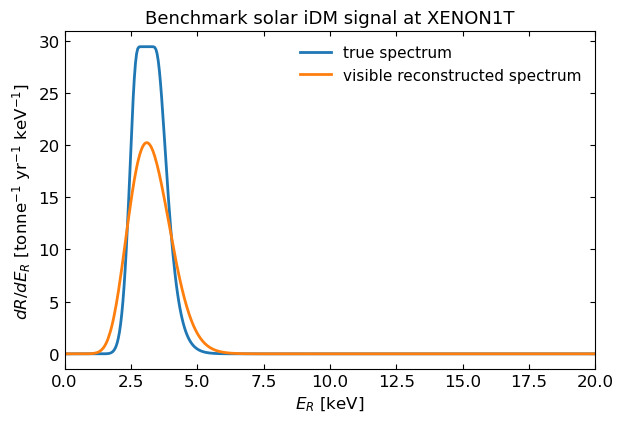

Visible events/(t yr) = 39.331


In [8]:
# Benchmark detector spectrum with the natural one-zone normalization

SPEC_TRUE_BENCH = dRdER_true_solar(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    ER_TRUE_GRID,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI
)

SPEC_VIS_BENCH, SPEC_SMEAR_BENCH = reconstructed_visible_spectrum(
    SPEC_TRUE_BENCH,
    ER_TRUE_GRID,
    ER_REC_GRID,
    E_EFF_KEV,
    EFF_VALS
)

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.plot(ER_TRUE_GRID, SPEC_TRUE_BENCH, lw=2.0, label="true spectrum")
ax.plot(ER_REC_GRID, SPEC_VIS_BENCH, lw=2.0, label="visible reconstructed spectrum")
ax.set_xlabel(r"$E_R\ [{\rm keV}]$")
ax.set_ylabel(r"$dR/dE_R\ [{\rm tonne}^{-1}\ {\rm yr}^{-1}\ {\rm keV}^{-1}]$")
ax.set_xlim(0.0, 20.0)
ax.set_title(r"Benchmark solar iDM signal at XENON1T")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Visible events/(t yr) = {trapz(SPEC_VIS_BENCH, ER_REC_GRID):.3f}")

In [9]:
# Figure 6 (left): scan in (mchi, delta) with the same natural normalization

MCHI_GRID_MEV  = np.linspace(2.0, 14.0, 400)
DELTA_GRID_KEV = np.linspace(0.05, 10.0, 400)

RATE_EVENTS = np.zeros((len(DELTA_GRID_KEV), len(MCHI_GRID_MEV)))

for j, mMeV in enumerate(MCHI_GRID_MEV):    
    mGeV = 1.0e-3 * mMeV
    if (j + 1) % 10 == 0:
        print(f"[{j + 1}/{len(MCHI_GRID_MEV)}]")
    for i, dkeV in enumerate(DELTA_GRID_KEV):
        RATE_EVENTS[i, j] = visible_event_rate_tyr(
            mGeV,
            dkeV,
            alpha_D=ALPHA_D_BENCH,
            r=RATIO_MA_MCHI
        )

[10/400]
[20/400]
[30/400]
[40/400]
[50/400]
[60/400]
[70/400]
[80/400]
[90/400]
[100/400]
[110/400]
[120/400]
[130/400]
[140/400]
[150/400]
[160/400]
[170/400]
[180/400]
[190/400]
[200/400]
[210/400]
[220/400]
[230/400]
[240/400]
[250/400]
[260/400]
[270/400]
[280/400]
[290/400]
[300/400]
[310/400]
[320/400]
[330/400]
[340/400]
[350/400]
[360/400]
[370/400]
[380/400]
[390/400]
[400/400]


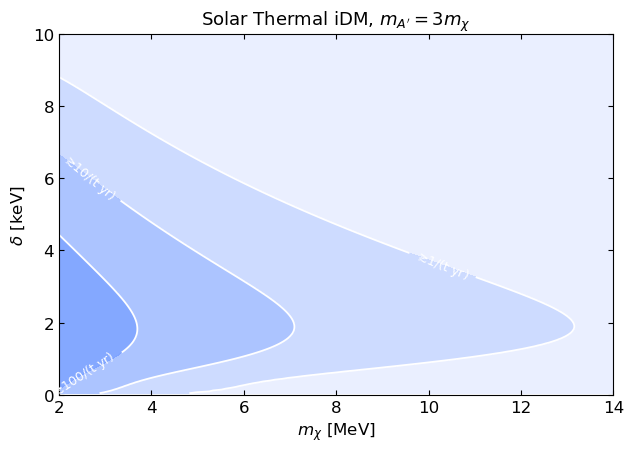

In [10]:
# Plot the Figure 6(left)-style XENON1T contours

LEVELS = [1.0, 10.0, 100.0]

fig, ax = plt.subplots(figsize=(6.5, 4.7))

ax.contourf(
    MCHI_GRID_MEV,
    DELTA_GRID_KEV,
    RATE_EVENTS,
    levels=[0.0, 1.0, 10.0, 100.0, np.max(RATE_EVENTS)],
    colors=["#e9efff", "#cbd9ff", "#a8c1ff", "#7da3ff"],
    alpha=0.95
)

cs = ax.contour(
    MCHI_GRID_MEV,
    DELTA_GRID_KEV,
    RATE_EVENTS,
    levels=LEVELS,
    colors="white",
    linewidths=1.3
)

ax.clabel(
    cs,
    fmt=lambda x: rf"$\gtrsim {int(x):d}/(\mathrm{{t\ yr}})$",
    inline=True,
    fontsize=9
)

ax.set_xlabel(r"$m_\chi\ [{\rm MeV}]$")
ax.set_ylabel(r"$\delta\ [{\rm keV}]$")
ax.set_xlim(2.0, 14.0)
ax.set_ylim(0.0, 10.0)
ax.set_title(r"Solar Thermal iDM, $m_{A^\prime}=3m_\chi$")

plt.tight_layout()
plt.show()

In [11]:
# Save outputs

SOLAR_IDM_ONEZONE_RESULTS = {
    "benchmark": {
        "mchi_MeV": MCHI_BENCH_MEV,
        "delta_keV": DELTA_BENCH_KEV,
        "dphi_fig4_K_keV": K_FIG4_KEV,
        "dphi_fig4_vals": DPHI_FIG4,
        "ER_true_grid": ER_TRUE_GRID,
        "ER_rec_grid": ER_REC_GRID,
        "spec_true_bench": SPEC_TRUE_BENCH,
        "spec_vis_bench": SPEC_VIS_BENCH,
        "visible_events_tyr": trapz(SPEC_VIS_BENCH, ER_REC_GRID),
    },
    "figure6_left": {
        "mchi_grid_MeV": MCHI_GRID_MEV,
        "delta_grid_keV": DELTA_GRID_KEV,
        "rate_events_tyr": RATE_EVENTS,
    }
}

# Weeks 6-7: Inclusion of the solar radial profiles

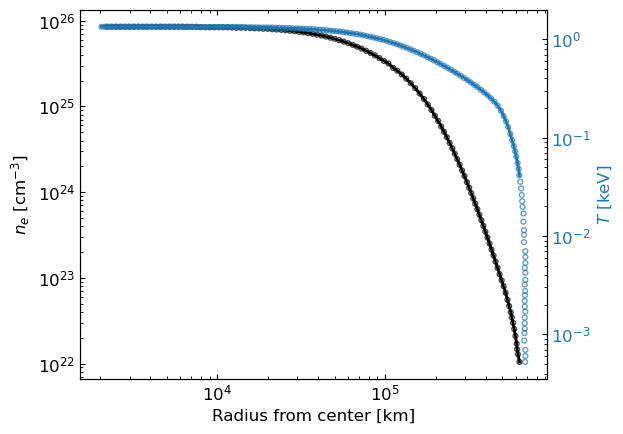

In [12]:
# Load solar radial profiles from CSV files and build interpolators
# Expected formats:
#   Temperature CSV: radius_km, temperature_K
#   Electron density CSV: radius_km, n_e_cm^-3

KELVIN_PER_KEV = 1.160451812e7
KM_TO_CM = 1.0e5
R_SUN_CM = 6.957e10

TEMP_PROFILE_CSV = "Temperature as a function of the radius.csv"
NE_PROFILE_CSV   = "Electron number density as a function of the radius.csv"

def load_two_col_csv(path):
    try:
        arr = np.genfromtxt(path, delimiter=",", comments="#")
        if arr.ndim == 1:
            raise ValueError("Trying semicolon-separated format")
    except Exception:
        arr = np.genfromtxt(path, delimiter=";", comments="#")
        if arr.ndim == 1:
            raise

    x = np.asarray(arr[:, 0], float)
    y = np.asarray(arr[:, 1], float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    order = np.argsort(x)
    return x[order], y[order]

def make_interp(x, y, *, logx=False, logy=False):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    if logx:
        if np.any(x <= 0):
            raise ValueError("logx=True but x has non-positive values.")
        x_work = np.log(x)
    else:
        x_work = x

    use_logy = logy and np.all(y > 0)
    y_work = np.log(y) if use_logy else y

    xmin, xmax = x_work[0], x_work[-1]

    def f(xq):
        xq = np.asarray(xq, float)
        xq_work = np.log(xq) if logx else xq
        xq_work = np.clip(xq_work, xmin, xmax)
        vals = np.interp(xq_work, x_work, y_work)
        return np.exp(vals) if use_logy else vals

    return f

# Load temperature profile: radius [km], T [K]
r_km_T, T_K = load_two_col_csv(TEMP_PROFILE_CSV)
r_cm_T = r_km_T * KM_TO_CM
T_keV = T_K / KELVIN_PER_KEV
T_of_r = make_interp(r_cm_T, T_keV, logx=False, logy=False)

# Load electron density profile: radius [km], n_e [cm^-3]
r_km_ne, ne_cm3 = load_two_col_csv(NE_PROFILE_CSV)
r_cm_ne = r_km_ne * KM_TO_CM
n_e_of_r = make_interp(r_cm_ne, ne_cm3, logx=False, logy=True)

# Common radial range effectively covered by both profiles
R_PROFILE_MAX_CM = min(r_cm_T[-1], r_cm_ne[-1], R_SUN_CM)

# Quick sanity plot in log-log scale
r_min_cm = max(min(r_cm_T[r_cm_T > 0].min(), r_cm_ne[r_cm_ne > 0].min()), 1.0)
r_plot_cm = np.logspace(np.log10(r_min_cm), np.log10(R_PROFILE_MAX_CM), 800)
r_plot_km = r_plot_cm / KM_TO_CM

fig, ax1 = plt.subplots(figsize=(6.4, 4.5))
ax2 = ax1.twinx()

# Electron density
ax1.loglog(r_plot_km, n_e_of_r(r_plot_cm), lw=2.0, color="black", label=r"$n_e(r)$")
ax1.scatter(r_km_ne[r_km_ne > 0], ne_cm3[r_km_ne > 0], s=12,
            facecolors="none", edgecolors="black", alpha=0.7)
ax1.set_xlabel("Radius from center [km]")
ax1.set_ylabel(r"$n_e\ [{\rm cm^{-3}}]$", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Temperature
ax2.loglog(r_plot_km, T_of_r(r_plot_cm), lw=2.0, color="tab:blue", label=r"$T(r)$")
ax2.scatter(r_km_T[r_km_T > 0], T_keV[r_km_T > 0], s=12,
            facecolors="none", edgecolors="tab:blue", alpha=0.7)
ax2.set_ylabel(r"$T\ [{\rm keV}]$", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.tight_layout()
plt.show()

In [13]:
# Radial generalization of the one-zone differential flux

def dphi_dKstar_solar_radial(mchi_GeV, delta_keV, Kgrid_keV, *, alpha_D=0.5, r=3.0, Nr=800):
    """
    Radial-profile generalization of the one-zone solar differential flux.

    This keeps the same benchmark DM-side approximation as the one-zone notebook:
      n_chi,sun ≈ n_inf * (v_esc / v_0)
    with the same constant focusing factor VESC_OVER_V0.

    What changes here is:
      n_e -> n_e(r)
      T   -> T(r)
      V   -> ∫ 4π r^2 dr
    """
    Kgrid_keV = np.asarray(Kgrid_keV, float)

    # Same benchmark DM normalization as in the one-zone notebook
    nchi_inf  = RHO0_GEV_CM3 / mchi_GeV
    nchi_sun  = nchi_inf * VESC_OVER_V0

    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    sigma_e  = sigma_e_contact_cm2(mchi_GeV, alpha_D=alpha_D, r=r)

    # Radial grid
    r_grid = np.linspace(0.0, R_PROFILE_MAX_CM, Nr)
    T_grid = np.maximum(T_of_r(r_grid), 1e-12)[None, :]
    ne_grid = n_e_of_r(r_grid)[None, :]

    shell_factor = (4.0 * np.pi * r_grid**2)[None, :]   # cm^2

    # K-dependent part
    vmin2 = vmin2_for_K(mchi_GeV, Kgrid_keV, delta_keV)[:, None]

    pref = sigma_e * C_CM_S * (mchi_keV / (2.0 * mu**2))
    thermal = np.sqrt(2.0 * M_E_KEV / (np.pi * T_grid))
    boltz   = np.exp(-(M_E_KEV / (2.0 * T_grid)) * vmin2)

    avg_local = pref * thermal * boltz   # <dσ/dK v>_r  [cm^3 s^-1 keV^-1]

    integrand_r = shell_factor * ne_grid * avg_local
    radial_integral = trapz(integrand_r, r_grid, axis=1)

    geom = nchi_sun / (4.0 * np.pi * AU_CM**2)
    return geom * radial_integral   # [cm^-2 s^-1 keV^-1]

def dphi_dKstar_shell_integrand(mchi_GeV, delta_keV, Kstar_keV, *, alpha_D=0.5, r=3.0, Nr=800):
    """
    Radial contribution to dPhi/dK* at a fixed K*.
    Useful for diagnostics: returns dPhi/dK*/dr integrand (up to the dr measure).
    """
    nchi_inf = RHO0_GEV_CM3 / mchi_GeV
    nchi_sun = nchi_inf * VESC_OVER_V0

    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    sigma_e  = sigma_e_contact_cm2(mchi_GeV, alpha_D=alpha_D, r=r)

    r_grid = np.linspace(0.0, R_PROFILE_MAX_CM, Nr)
    T_grid = np.maximum(T_of_r(r_grid), 1e-12)
    ne_grid = n_e_of_r(r_grid)

    vmin2 = vmin2_for_K(mchi_GeV, np.array([Kstar_keV]), delta_keV)[0]

    pref = sigma_e * C_CM_S * (mchi_keV / (2.0 * mu**2))
    avg_local = pref * np.sqrt(2.0 * M_E_KEV / (np.pi * T_grid)) * np.exp(-(M_E_KEV / (2.0 * T_grid)) * vmin2)

    geom = nchi_sun / (4.0 * np.pi * AU_CM**2)
    integrand = geom * (4.0 * np.pi * r_grid**2) * ne_grid * avg_local

    return r_grid, integrand

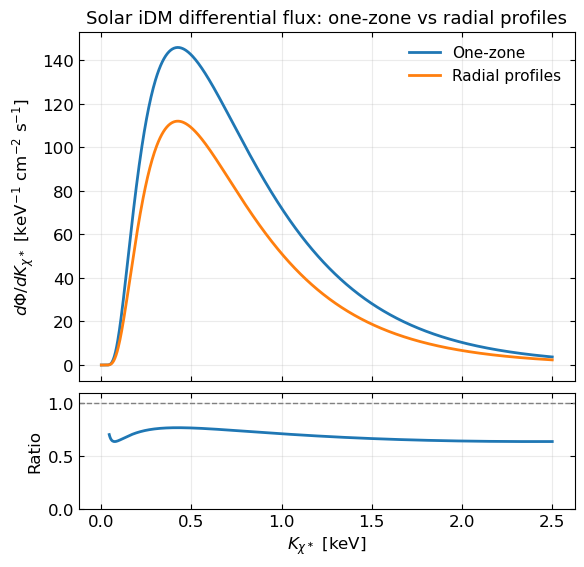

One-zone peak flux  = 145.898 keV^-1 cm^-2 s^-1
Radial peak flux    = 112.037 keV^-1 cm^-2 s^-1
Peak ratio          = 0.768


In [14]:
# Benchmark comparison: one-zone vs radial-profile differential flux

K_FIG4_RADIAL_KEV = np.linspace(1e-3, 2.5, 800)

DPHI_ONEZONE = dphi_dKstar_solar(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    K_FIG4_RADIAL_KEV,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI
)

DPHI_RADIAL = dphi_dKstar_solar_radial(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    K_FIG4_RADIAL_KEV,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI,
    Nr=800
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6.4, 6.2), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

ax1.plot(K_FIG4_RADIAL_KEV, DPHI_ONEZONE, lw=2.0, label="One-zone")
ax1.plot(K_FIG4_RADIAL_KEV, DPHI_RADIAL, lw=2.0, label="Radial profiles")
ax1.set_ylabel(r"$d\Phi/dK_{\chi^\ast}\ [{\rm keV}^{-1}\ {\rm cm}^{-2}\ {\rm s}^{-1}]$")
ax1.set_title(r"Solar iDM differential flux: one-zone vs radial profiles")
ax1.legend(frameon=False)
ax1.grid(alpha=0.25)

threshold = 1e-3 * np.max(DPHI_ONEZONE)

ratio = np.full_like(DPHI_RADIAL, np.nan)
mask = DPHI_ONEZONE > threshold
ratio[mask] = DPHI_RADIAL[mask] / DPHI_ONEZONE[mask]

ax2.plot(K_FIG4_RADIAL_KEV, ratio, lw=2.0)
ax2.axhline(1.0, color="gray", ls="--", lw=1.0)
ax2.set_xlabel(r"$K_{\chi^\ast}\ [{\rm keV}]$")
ax2.set_ylabel("Ratio")
ax2.set_ylim(0.0, 1.1)
ax2.grid(alpha=0.25)

plt.show()

print(f"One-zone peak flux  = {DPHI_ONEZONE.max():.3f} keV^-1 cm^-2 s^-1")
print(f"Radial peak flux    = {DPHI_RADIAL.max():.3f} keV^-1 cm^-2 s^-1")
print(f"Peak ratio          = {DPHI_RADIAL.max()/DPHI_ONEZONE.max():.3f}")

In [15]:
# Save radial-profile differential-flux results

SOLAR_IDM_RADIAL_FLUX_RESULTS = {
    "profiles": {
        "r_km_T": r_km_T,
        "T_K": T_K,
        "r_km_ne": r_km_ne,
        "ne_cm3": ne_cm3,
        "R_profile_max_cm": R_PROFILE_MAX_CM,
    },
    "benchmark_flux": {
        "K_keV": K_FIG4_RADIAL_KEV,
        "dphi_onezone": DPHI_ONEZONE,
        "dphi_radial": DPHI_RADIAL,
    }
}

# Week 8-9: SHM vs. LMC comparison

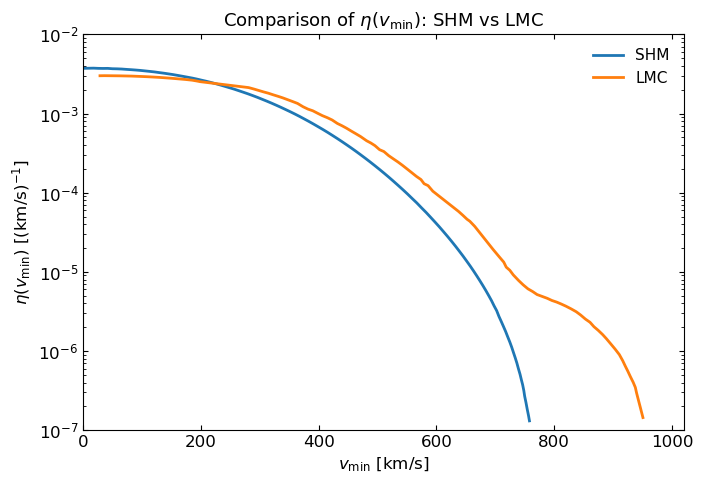

In [16]:
# SHM vs LMC: load the digitized eta(vmin) curves and convert them to physical units
# The digitized CSV values come from a plot whose y-axis is:
#   [10^{-3} (km/s)^{-1}]
# so we multiply by 1e-3 immediately after loading.

SHM_CSV = "SHM.csv"
LMC_CSV = "LMC.csv"

vmin_shm, eta_shm = load_two_col_csv(SHM_CSV)
vmin_lmc, eta_lmc = load_two_col_csv(LMC_CSV)

# Convert from plotted units [10^{-3} (km/s)^{-1}] to physical units [(km/s)^{-1}]
eta_shm = 1.0e-3 * eta_shm
eta_lmc = 1.0e-3 * eta_lmc

fig, ax = plt.subplots(figsize=(7.2, 5.0))

mask_shm = eta_shm > 0.0
mask_lmc = eta_lmc > 0.0

ax.plot(vmin_shm[mask_shm], eta_shm[mask_shm], lw=2.0, label="SHM")
ax.plot(vmin_lmc[mask_lmc], eta_lmc[mask_lmc], lw=2.0, label="LMC")

ax.set_yscale("log")
ax.set_xlim(0.0, 1020.0)
ax.set_ylim(1.0e-7, 1.0e-2)

ax.set_xlabel(r"$v_{\min}\ [{\rm km/s}]$")
ax.set_ylabel(r"$\eta(v_{\min})\ [({\rm km/s})^{-1}]$")
ax.set_title(r"Comparison of $\eta(v_{\min})$: SHM vs LMC")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

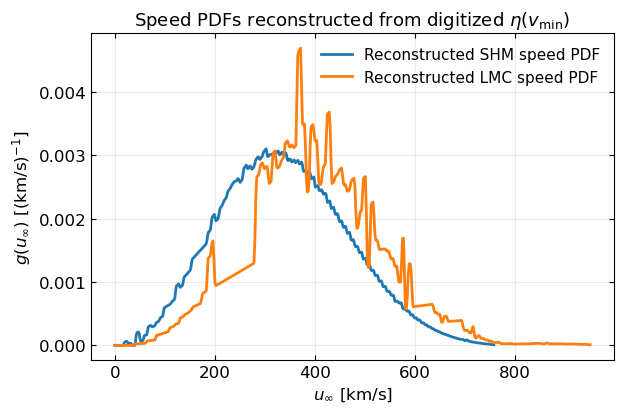

In [17]:
# Reconstruct speed PDFs from the digitized eta(vmin) curves
# Here eta_shm and eta_lmc are already in physical units [(km/s)^-1]

from scipy.special import erf

C_KMS = 299_792.458

def make_eta_interp_from_samples(v_kms, eta_vals):
    v = np.asarray(v_kms, float)
    y = np.asarray(eta_vals, float)

    mask = np.isfinite(v) & np.isfinite(y) & (v >= 0.0) & (y >= 0.0)
    v, y = v[mask], y[mask]

    order = np.argsort(v)
    v, y = v[order], y[order]

    vmin0 = v[0]
    vmax0 = v[-1]
    y0 = y[0]

    def eta_fn(vq_kms):
        vq = np.asarray(vq_kms, float)
        out = np.interp(vq, v, y, left=y0, right=0.0)
        out = np.where(vq < vmin0, y0, out)
        out = np.where(vq > vmax0, 0.0, out)
        return out

    return eta_fn

def speed_pdf_from_eta_samples(v_kms, eta_vals, Nu=500):
    eta_fn = make_eta_interp_from_samples(v_kms, eta_vals)

    vmax = float(np.max(v_kms))
    umin = 1.0e-3
    ugrid = np.linspace(umin, vmax, Nu)

    eta_grid = eta_fn(ugrid)
    deta_du = np.gradient(eta_grid, ugrid)

    g_u = -ugrid * deta_du
    g_u = np.clip(g_u, 0.0, None)

    norm = trapz(g_u, ugrid)
    if norm <= 0.0:
        raise RuntimeError("Could not reconstruct a positive speed PDF from the eta(vmin) curve.")

    g_u /= norm
    return eta_fn, ugrid, g_u

eta_shm_fn, u_shm_kms, g_shm = speed_pdf_from_eta_samples(vmin_shm, eta_shm)
eta_lmc_fn, u_lmc_kms, g_lmc = speed_pdf_from_eta_samples(vmin_lmc, eta_lmc)

# Optional sanity check
fig, ax = plt.subplots(figsize=(6.4, 4.3))
ax.plot(u_shm_kms, g_shm, lw=2.0, label="Reconstructed SHM speed PDF")
ax.plot(u_lmc_kms, g_lmc, lw=2.0, label="Reconstructed LMC speed PDF")
ax.set_xlabel(r"$u_\infty\ [{\rm km/s}]$")
ax.set_ylabel(r"$g(u_\infty)\ [({\rm km/s})^{-1}]$")
ax.set_title(r"Speed PDFs reconstructed from digitized $\eta(v_{\min})$")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Simple escape-speed profile used to map asymptotic halo speed u_infty to local speed w(r)
VESC_CORE_KMS = 1380.0
VESC_SURF_KMS = 617.0

def vesc_of_r(r_cm):
    x = np.asarray(r_cm, float) / R_SUN_CM
    v_kms = VESC_CORE_KMS * (1.0 - x * x) + VESC_SURF_KMS * (x * x)
    return v_kms / C_KMS   # dimensionless (v/c)

def eta_electron_drift(vmin_c, w_c, T_keV):
    """
    Mean inverse relative speed for a Maxwell-Boltzmann electron bath at temperature T_keV,
    seen by a DM particle moving with speed w_c (dimensionless, in units of c).
    """
    a = np.sqrt(2.0 * T_keV / M_E_KEV)

    vmin_b, w_b = np.broadcast_arrays(np.asarray(vmin_c, float), np.asarray(w_c, float))
    out = np.empty_like(vmin_b)

    mask = np.abs(w_b) > 1e-12
    out[mask] = (
        erf((vmin_b[mask] + w_b[mask]) / a) -
        erf((vmin_b[mask] - w_b[mask]) / a)
    ) / (2.0 * w_b[mask])

    out[~mask] = 2.0 * np.exp(-(vmin_b[~mask] / a)**2) / (np.sqrt(np.pi) * a)
    return out

def dphi_dKstar_solar_radial_halo(mchi_GeV, delta_keV, Kgrid_keV, u_grid_kms, g_u,
                                  *, alpha_D=0.5, r=3.0, Nr=250):
    """
    Differential flux with:
      - solar radial profiles T(r), n_e(r)
      - incident-DM speed integral over g(u_infty)
      - local speed mapping w(r,u) = sqrt(u^2 + vesc(r)^2)
    """
    Kgrid_keV = np.asarray(Kgrid_keV, float)

    n_inf = RHO0_GEV_CM3 / mchi_GeV
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu = mu_keV(mchi_GeV)
    sigma_e = sigma_e_contact_cm2(mchi_GeV, alpha_D=alpha_D, r=r)

    vmin_rel = vmin_of_K(mchi_GeV, Kgrid_keV, delta_keV)

    u_grid_kms = np.asarray(u_grid_kms, float)
    g_u = np.asarray(g_u, float)
    u_grid_c = u_grid_kms / C_KMS

    pref = n_inf * sigma_e * C_CM_S * (mchi_keV / (2.0 * mu**2)) / (4.0 * np.pi * AU_CM**2)

    r_grid = np.linspace(0.0, R_PROFILE_MAX_CM, Nr)
    radial_integrand = np.zeros((Nr, len(Kgrid_keV)))

    for i, rr in enumerate(r_grid):
        Tloc = max(float(T_of_r(rr)), 1.0e-12)
        neloc = float(n_e_of_r(rr))
        vesc_loc = float(vesc_of_r(rr))

        w_grid_c = np.sqrt(u_grid_c**2 + vesc_loc**2)
        density_enh = w_grid_c / np.maximum(u_grid_c, 1.0e-12)

        inv_rel = eta_electron_drift(vmin_rel[:, None], w_grid_c[None, :], Tloc)
        u_avg = trapz(g_u[None, :] * density_enh[None, :] * inv_rel, u_grid_kms, axis=1)

        radial_integrand[i, :] = 4.0 * np.pi * rr**2 * neloc * u_avg

    radial_int = trapz(radial_integrand, r_grid, axis=0)
    return pref * radial_int

In [18]:
# Compute the benchmark fluxes once

K_COMPARE_KEV = np.linspace(1e-3, 2.5, 800)

DPHI_ONEZONE = dphi_dKstar_solar(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    K_COMPARE_KEV,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI
)

DPHI_RADIAL_REST = dphi_dKstar_solar_radial(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    K_COMPARE_KEV,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI,
    Nr=800
)

DPHI_RADIAL_SHM_FULL = dphi_dKstar_solar_radial_halo(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    K_COMPARE_KEV,
    u_shm_kms,
    g_shm,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI,
    Nr=250
)

DPHI_RADIAL_LMC_FULL = dphi_dKstar_solar_radial_halo(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    K_COMPARE_KEV,
    u_lmc_kms,
    g_lmc,
    alpha_D=ALPHA_D_BENCH,
    r=RATIO_MA_MCHI,
    Nr=250
)

In [19]:
# Helper for flux-comparison plots with a ratio panel

def plot_flux_comparison_with_ratio(
    K_keV,
    curves,
    *,
    title,
    ratio_reference_key,
    ylabel=r"$d\Phi/dK_{\chi^\ast}\ [{\rm keV}^{-1}\ {\rm cm}^{-2}\ {\rm s}^{-1}]$",
):
    """
    curves: ordered dict-like mapping
        key -> {
            "y": array,
            "label": str,
            "color": optional matplotlib color
        }

    ratio_reference_key:
        key of the denominator curve
    """
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(6.6, 6.2), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
    )

    # Top panel
    for key, item in curves.items():
        ax1.plot(
            K_keV,
            item["y"],
            lw=2.0,
            label=item["label"],
            color=item.get("color", None),
        )

    ax1.set_ylabel(ylabel)
    ax1.set_title(title)
    ax1.legend(frameon=False)
    ax1.grid(alpha=0.25)

    # Ratio panel
    yref = curves[ratio_reference_key]["y"]
    threshold = 1e-3 * np.max(yref)
    mask = yref > threshold

    for key, item in curves.items():
        if key == ratio_reference_key:
            continue

        ratio = np.full_like(item["y"], np.nan)
        ratio[mask] = item["y"][mask] / yref[mask]

        ax2.plot(
            K_keV,
            ratio,
            lw=2.0,
            color=item.get("color", None),
            label=f'{item["label"]} / {curves[ratio_reference_key]["label"]}',
        )

    ax2.axhline(1.0, color="gray", ls="--", lw=1.0)
    ax2.set_xlabel(r"$K_{\chi^\ast}\ [{\rm keV}]$")
    ax2.set_ylabel("Ratio")
    ax2.grid(alpha=0.25)

    plt.show()

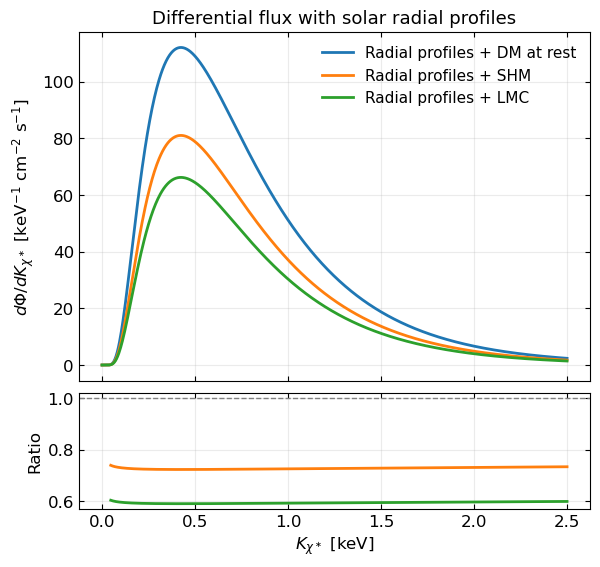

Peak radial + rest = 112.037
Peak radial + SHM  = 81.004
Peak radial + LMC  = 66.194


In [20]:
# Plot 1: radial profiles + DM-at-rest vs SHM vs LMC

curves_plot1 = {
    "rest": {
        "y": DPHI_RADIAL_REST,
        "label": "Radial profiles + DM at rest",
        "color": "tab:blue",
    },
    "shm": {
        "y": DPHI_RADIAL_SHM_FULL,
        "label": "Radial profiles + SHM",
        "color": "tab:orange",
    },
    "lmc": {
        "y": DPHI_RADIAL_LMC_FULL,
        "label": "Radial profiles + LMC",
        "color": "tab:green",
    },
}

plot_flux_comparison_with_ratio(
    K_COMPARE_KEV,
    curves_plot1,
    title="Differential flux with solar radial profiles",
    ratio_reference_key="rest",
)

print(f"Peak radial + rest = {DPHI_RADIAL_REST.max():.3f}")
print(f"Peak radial + SHM  = {DPHI_RADIAL_SHM_FULL.max():.3f}")
print(f"Peak radial + LMC  = {DPHI_RADIAL_LMC_FULL.max():.3f}")

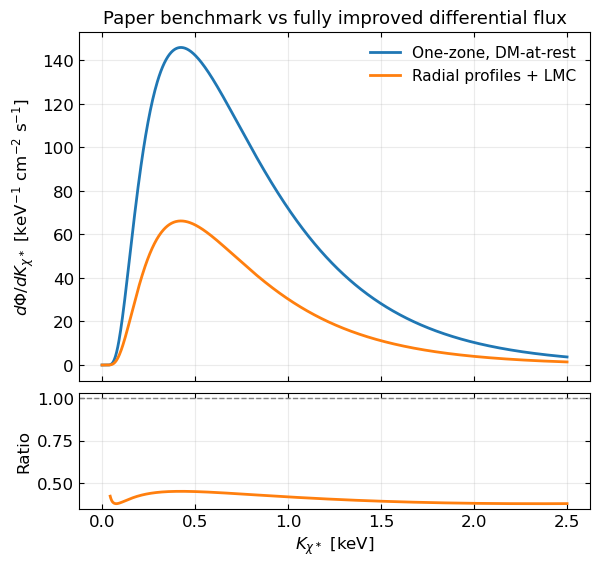

Peak one-zone            = 145.898
Peak radial + LMC (full) = 66.194
Peak ratio               = 0.454


In [21]:
# Plot 2: one-zone paper benchmark vs fully improved radial profiles + LMC

curves_plot2 = {
    "onezone": {
        "y": DPHI_ONEZONE,
        "label": "One-zone, DM-at-rest",
        "color": "tab:blue",
    },
    "lmc": {
        "y": DPHI_RADIAL_LMC_FULL,
        "label": "Radial profiles + LMC",
        "color": "tab:orange",
    },
}

plot_flux_comparison_with_ratio(
    K_COMPARE_KEV,
    curves_plot2,
    title="Paper benchmark vs fully improved differential flux",
    ratio_reference_key="onezone",
)

print(f"Peak one-zone            = {DPHI_ONEZONE.max():.3f}")
print(f"Peak radial + LMC (full) = {DPHI_RADIAL_LMC_FULL.max():.3f}")
print(f"Peak ratio               = {DPHI_RADIAL_LMC_FULL.max()/DPHI_ONEZONE.max():.3f}")

In [22]:
# Save results

SOLAR_IDM_FULL_HALO_FLUX_RESULTS = {
    "K_keV": K_COMPARE_KEV,
    "onezone": DPHI_ONEZONE,
    "radial_rest": DPHI_RADIAL_REST,
    "radial_shm_full": DPHI_RADIAL_SHM_FULL,
    "radial_lmc_full": DPHI_RADIAL_LMC_FULL,
    "u_shm_kms": u_shm_kms,
    "g_shm": g_shm,
    "u_lmc_kms": u_lmc_kms,
    "g_lmc": g_lmc,
}

# Weeks 10-11: Inclusion of proton and Helium nuclei channels

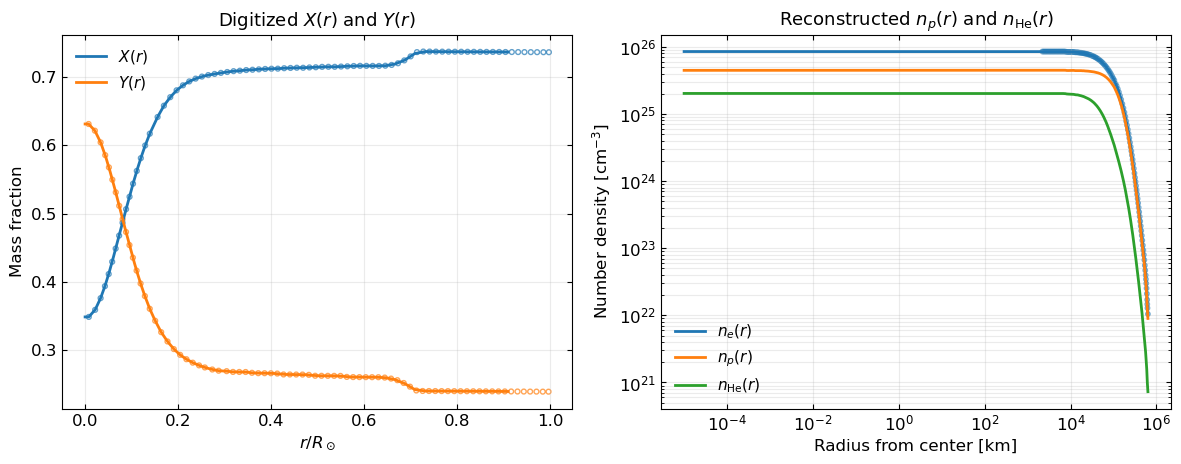

In [23]:
# Reconstruct n_p(r) and n_He(r) from:
#   - digitized hydrogen mass fraction X(r)
#   - digitized helium-4 mass fraction Y(r)
#   - existing electron number density profile n_e(r)

HYDROGEN_ABUNDANCE_CSV = "Hydrogen abundance.csv"
HELIUM4_ABUNDANCE_CSV  = "Helium-4 abundance.csv"

# Load digitized X(r) and Y(r)
# Assumed format: column 1 = r/R_sun, column 2 = abundance mass fraction
rfrac_X, X_vals = load_two_col_csv(HYDROGEN_ABUNDANCE_CSV)
rfrac_Y, Y_vals = load_two_col_csv(HELIUM4_ABUNDANCE_CSV)

# Convert radius fraction to cm
r_cm_X = rfrac_X * R_SUN_CM
r_cm_Y = rfrac_Y * R_SUN_CM

# Interpolators for X(r) and Y(r)
X_of_r = make_interp(r_cm_X, X_vals, logx=False, logy=False)
Y_of_r = make_interp(r_cm_Y, Y_vals, logx=False, logy=False)

# Common radial range
R_PROFILE_MAX_CHANNEL_CM = min(R_PROFILE_MAX_CM, r_cm_X[-1], r_cm_Y[-1], R_SUN_CM)

# Reconstruct n_p and n_He from:
#   r(r) = n_He / n_p = Y / (4X)
#   n_e = n_p + 2 n_He = n_p (1 + 2r)
def he_to_h_ratio_of_r(r_cm):
    X = np.maximum(X_of_r(r_cm), 1.0e-12)
    Y = np.maximum(Y_of_r(r_cm), 0.0)
    return Y / (4.0 * X)

def n_p_reconstructed_of_r(r_cm):
    rr = he_to_h_ratio_of_r(r_cm)
    return n_e_of_r(r_cm) / (1.0 + 2.0 * rr)

def n_he_reconstructed_of_r(r_cm):
    rr = he_to_h_ratio_of_r(r_cm)
    return rr * n_e_of_r(r_cm) / (1.0 + 2.0 * rr)

# Sample arrays for plotting
r_plot_cm = np.logspace(np.log10(1.0), np.log10(R_PROFILE_MAX_CHANNEL_CM), 800)
r_plot_km = r_plot_cm / KM_TO_CM
r_plot_frac = r_plot_cm / R_SUN_CM

X_plot = X_of_r(r_plot_cm)
Y_plot = Y_of_r(r_plot_cm)
n_p_plot = n_p_reconstructed_of_r(r_plot_cm)
n_he_plot = n_he_reconstructed_of_r(r_plot_cm)

# Store sampled arrays if you want them explicitly
n_p_cm3 = n_p_reconstructed_of_r(r_cm_X)
n_he_cm3 = n_he_reconstructed_of_r(r_cm_Y)

# Use these as the channel density functions downstream
n_p_of_r = n_p_reconstructed_of_r
n_he_of_r = n_he_reconstructed_of_r

# Plot: left panel = X and Y, right panel = reconstructed n_p and n_He
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.8))

# Left: abundances
ax1.plot(r_plot_frac, X_plot, lw=2.0, label=r"$X(r)$")
ax1.plot(r_plot_frac, Y_plot, lw=2.0, label=r"$Y(r)$")

ax1.scatter(rfrac_X, X_vals, s=12, facecolors="none", edgecolors="C0", alpha=0.7)
ax1.scatter(rfrac_Y, Y_vals, s=12, facecolors="none", edgecolors="C1", alpha=0.7)

ax1.set_xlabel(r"$r/R_\odot$")
ax1.set_ylabel("Mass fraction")
ax1.set_title(r"Digitized $X(r)$ and $Y(r)$")
ax1.grid(alpha=0.25)
ax1.legend(frameon=False)

# Right: reconstructed number densities
ax2.loglog(r_plot_km, n_e_of_r(r_plot_cm), lw=2.0, label=r"$n_e(r)$")
ax2.loglog(r_plot_km, n_p_plot, lw=2.0, label=r"$n_p(r)$")
ax2.loglog(r_plot_km, n_he_plot, lw=2.0, label=r"$n_{\rm He}(r)$")

ax2.scatter(r_km_ne[r_km_ne > 0], ne_cm3[r_km_ne > 0], s=10, facecolors="none", edgecolors="C0", alpha=0.6)

ax2.set_xlabel("Radius from center [km]")
ax2.set_ylabel(r"Number density [cm$^{-3}$]")
ax2.set_title(r"Reconstructed $n_p(r)$ and $n_{\rm He}(r)$")
ax2.grid(alpha=0.25, which="both")
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

In [24]:
# Target-dependent helpers for e, p and He channels

M_P_KEV  = 938_272.0813
M_HE_KEV = 3_727_379.378

TARGETS = {
    "e": {
        "label": "e",
        "mass_keV": M_E_KEV,
        "charge": 1.0,
        "density_fn": n_e_of_r,
        "color": "tab:blue",
    },
    "p": {
        "label": "p",
        "mass_keV": M_P_KEV,
        "charge": 1.0,
        "density_fn": n_p_of_r,
        "color": "tab:orange",
    },
    "He": {
        "label": r"$^4$He",
        "mass_keV": M_HE_KEV,
        "charge": 2.0,
        "density_fn": n_he_of_r,
        "color": "tab:green",
    },
}

def mu_target_keV(mchi_GeV, mT_keV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return (mchi_keV * mT_keV) / (mchi_keV + mT_keV)

def sigma_target_cm2(mchi_GeV, target_key, *, alpha_D=0.5, r_ratio=3.0):
    sigma_e = sigma_e_contact_cm2(mchi_GeV, alpha_D=alpha_D, r=r_ratio)

    if target_key == "e":
        return sigma_e

    mu_e = mu_target_keV(mchi_GeV, M_E_KEV)
    tgt = TARGETS[target_key]
    mu_T = mu_target_keV(mchi_GeV, tgt["mass_keV"])
    ZT = tgt["charge"]

    return sigma_e * (mu_T**2 / mu_e**2) * (ZT**2)

def vmin_of_K_target(mchi_GeV, Kstar_keV, delta_keV, mT_keV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu_T = mu_target_keV(mchi_GeV, mT_keV)
    K = np.maximum(np.asarray(Kstar_keV, float), 1e-300)
    return ((mchi_keV * K) / mu_T + delta_keV) / np.sqrt(2.0 * mchi_keV * K)

def inv_rel_mb_drift(vmin_c, w_c, T_keV, mT_keV):
    a = np.sqrt(2.0 * T_keV / mT_keV)

    vmin_b, w_b = np.broadcast_arrays(np.asarray(vmin_c, float), np.asarray(w_c, float))
    out = np.empty_like(vmin_b)

    mask = np.abs(w_b) > 1e-12
    out[mask] = (
        erf((vmin_b[mask] + w_b[mask]) / a) -
        erf((vmin_b[mask] - w_b[mask]) / a)
    ) / (2.0 * w_b[mask])

    out[~mask] = 2.0 * np.exp(-(vmin_b[~mask] / a)**2) / (np.sqrt(np.pi) * a)
    return out

def dphi_dKstar_solar_radial_halo_target(
    mchi_GeV,
    delta_keV,
    Kgrid_keV,
    u_grid_kms,
    g_u,
    target_key,
    *,
    alpha_D=0.5,
    r_ratio=3.0,
    Nr=250,
):
    Kgrid_keV = np.asarray(Kgrid_keV, float)
    tgt = TARGETS[target_key]

    n_inf = RHO0_GEV_CM3 / mchi_GeV
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mT_keV = tgt["mass_keV"]
    mu_T = mu_target_keV(mchi_GeV, mT_keV)
    sigma_T = sigma_target_cm2(mchi_GeV, target_key, alpha_D=alpha_D, r_ratio=r_ratio)

    vmin_rel = vmin_of_K_target(mchi_GeV, Kgrid_keV, delta_keV, mT_keV)

    u_grid_kms = np.asarray(u_grid_kms, float)
    g_u = np.asarray(g_u, float)
    u_grid_c = u_grid_kms / C_KMS

    pref = n_inf * sigma_T * C_CM_S * (mchi_keV / (2.0 * mu_T**2)) / (4.0 * np.pi * AU_CM**2)

    r_grid = np.linspace(0.0, R_PROFILE_MAX_CHANNEL_CM, Nr)
    radial_integrand = np.zeros((Nr, len(Kgrid_keV)))

    for i, rr in enumerate(r_grid):
        Tloc = max(float(T_of_r(rr)), 1.0e-12)
        nTloc = float(tgt["density_fn"](rr))
        vesc_loc = float(vesc_of_r(rr))

        w_grid_c = np.sqrt(u_grid_c**2 + vesc_loc**2)
        density_enh = w_grid_c / np.maximum(u_grid_c, 1.0e-12)

        inv_rel = inv_rel_mb_drift(vmin_rel[:, None], w_grid_c[None, :], Tloc, mT_keV)
        u_avg = trapz(g_u[None, :] * density_enh[None, :] * inv_rel, u_grid_kms, axis=1)

        radial_integrand[i, :] = 4.0 * np.pi * rr**2 * nTloc * u_avg

    radial_int = trapz(radial_integrand, r_grid, axis=0)
    return pref * radial_int

def choose_Kmax_target(mchi_MeV, delta_keV, mT_keV, *, Tsun_keV=T_SUN_KEV, tail_tol=1e-8, peak_factor=8.0):
    mchi_keV = mchi_MeV * 1.0e3
    mu_T = (mchi_keV * mT_keV) / (mchi_keV + mT_keV)

    a = mT_keV / (2.0 * Tsun_keV)
    beta = a * mchi_keV / (2.0 * mu_T**2)

    K_tail = np.log(1.0 / tail_tol) / beta
    K_peak = delta_keV * mu_T / mT_keV

    return float(min(max(peak_factor * K_peak, K_tail, 1.0e-4), 50.0))

HALOS = {
    "SHM": {"u_kms": u_shm_kms, "g_u": g_shm},
    "LMC": {"u_kms": u_lmc_kms, "g_u": g_lmc},
}

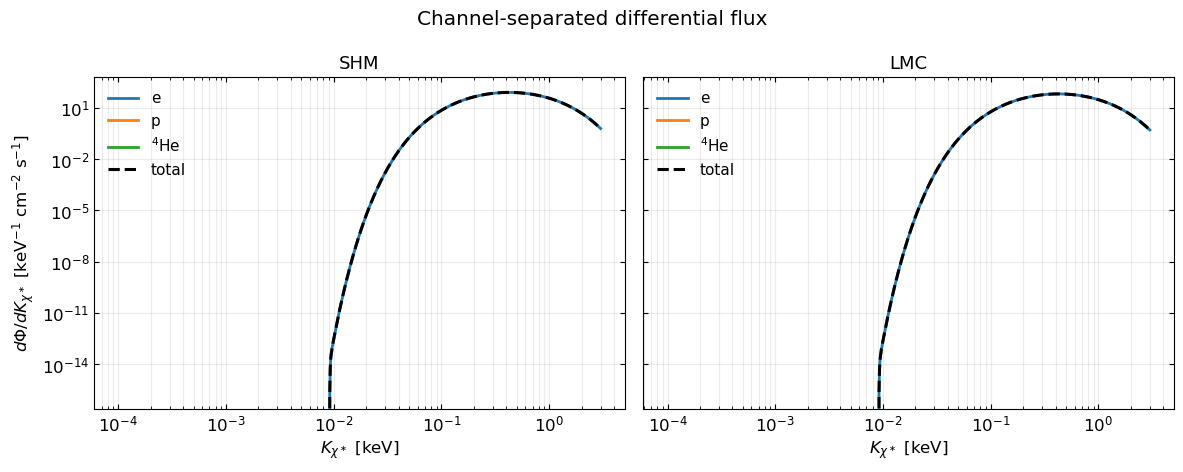

In [25]:
# Benchmark spectra for e, p, He and total in SHM and LMC

K_CHANNEL_KEV = np.logspace(-4, np.log10(3.0), 1000)

def channel_spectra_for_halo(mchi_GeV, delta_keV, halo_key, *, alpha_D=0.5, r_ratio=3.0, Nr=250):
    halo = HALOS[halo_key]
    spectra = {}

    total = np.zeros_like(K_CHANNEL_KEV)
    for key in ["e", "p", "He"]:
        y = dphi_dKstar_solar_radial_halo_target(
            mchi_GeV,
            delta_keV,
            K_CHANNEL_KEV,
            halo["u_kms"],
            halo["g_u"],
            key,
            alpha_D=alpha_D,
            r_ratio=r_ratio,
            Nr=Nr,
        )
        spectra[key] = y
        total += y

    spectra["total"] = total
    return spectra

spectra_shm = channel_spectra_for_halo(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    "SHM",
    alpha_D=ALPHA_D_BENCH,
    r_ratio=RATIO_MA_MCHI,
)

spectra_lmc = channel_spectra_for_halo(
    mchi_bench_GeV,
    DELTA_BENCH_KEV,
    "LMC",
    alpha_D=ALPHA_D_BENCH,
    r_ratio=RATIO_MA_MCHI,
)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharey=True)

for ax, spectra, halo_name in zip(axes, [spectra_shm, spectra_lmc], ["SHM", "LMC"]):
    for key in ["e", "p", "He"]:
        ax.loglog(
            K_CHANNEL_KEV,
            spectra[key],
            lw=2.0,
            color=TARGETS[key]["color"],
            label=TARGETS[key]["label"],
        )

    ax.loglog(K_CHANNEL_KEV, spectra["total"], lw=2.2, color="black", ls="--", label="total")
    ax.set_xlabel(r"$K_{\chi^\ast}\ [{\rm keV}]$")
    ax.set_title(halo_name)
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)

axes[0].set_ylabel(r"$d\Phi/dK_{\chi^\ast}\ [{\rm keV}^{-1}\ {\rm cm}^{-2}\ {\rm s}^{-1}]$")
fig.suptitle("Channel-separated differential flux")
plt.tight_layout()
plt.show()

In [26]:
# Integrated produced flux per channel

def integrated_flux_target(mchi_GeV, delta_keV, target_key, halo_key, *, alpha_D=0.5, r_ratio=3.0, Nr=180, NK=500):
    halo = HALOS[halo_key]
    Kmax = choose_Kmax_target(mchi_GeV * 1.0e3, delta_keV, TARGETS[target_key]["mass_keV"])
    Kmin = 1.0e-5
    Kgrid = np.logspace(np.log10(Kmin), np.log10(Kmax), NK)

    dphi = dphi_dKstar_solar_radial_halo_target(
        mchi_GeV,
        delta_keV,
        Kgrid,
        halo["u_kms"][::4],
        halo["g_u"][::4] / trapz(halo["g_u"][::4], halo["u_kms"][::4]),
        target_key,
        alpha_D=alpha_D,
        r_ratio=r_ratio,
        Nr=Nr,
    )
    return trapz(dphi, Kgrid)

def integrated_flux_total(mchi_GeV, delta_keV, halo_key, *, alpha_D=0.5, r_ratio=3.0, Nr=180, NK=500):
    return sum(
        integrated_flux_target(
            mchi_GeV, delta_keV, key, halo_key,
            alpha_D=alpha_D, r_ratio=r_ratio, Nr=Nr, NK=NK
        )
        for key in ["e", "p", "He"]
    )

In [35]:
# Parameter-space maps for the channel comparison
# Change HALO_FOR_CHANNEL_MAPS to "LMC" to rerun the same comparison in SHM.

HALO_FOR_CHANNEL_MAPS = "LMC"

MCHI_GRID_MEV = np.logspace(np.log10(1.0), np.log10(50.0), 20)
DELTA_GRID_KEV = np.logspace(np.log10(1.0e-3), np.log10(10.0), 20)

PHI_E_MAP  = np.zeros((len(DELTA_GRID_KEV), len(MCHI_GRID_MEV)))
PHI_P_MAP  = np.zeros_like(PHI_E_MAP)
PHI_HE_MAP = np.zeros_like(PHI_E_MAP)
PHI_TOT_MAP = np.zeros_like(PHI_E_MAP)

for j, mMeV in enumerate(MCHI_GRID_MEV):
    mGeV = 1.0e-3 * mMeV
    print(f"[{j+1}/{len(MCHI_GRID_MEV)}]")
    for i, dkeV in enumerate(DELTA_GRID_KEV):
        PHI_E_MAP[i, j] = integrated_flux_target(
            mGeV, dkeV, "e", HALO_FOR_CHANNEL_MAPS,
            alpha_D=ALPHA_D_BENCH, r_ratio=RATIO_MA_MCHI
        )
        PHI_P_MAP[i, j] = integrated_flux_target(
            mGeV, dkeV, "p", HALO_FOR_CHANNEL_MAPS,
            alpha_D=ALPHA_D_BENCH, r_ratio=RATIO_MA_MCHI
        )
        PHI_HE_MAP[i, j] = integrated_flux_target(
            mGeV, dkeV, "He", HALO_FOR_CHANNEL_MAPS,
            alpha_D=ALPHA_D_BENCH, r_ratio=RATIO_MA_MCHI
        )
        PHI_TOT_MAP[i, j] = PHI_E_MAP[i, j] + PHI_P_MAP[i, j] + PHI_HE_MAP[i, j]

[1/20]
[2/20]
[3/20]
[4/20]
[5/20]
[6/20]
[7/20]
[8/20]
[9/20]
[10/20]
[11/20]
[12/20]
[13/20]
[14/20]
[15/20]
[16/20]
[17/20]
[18/20]
[19/20]
[20/20]


/tmp/ipykernel_69785/3325344352.py:14: RuntimeWarning: divide by zero encountered in log10
  Zplot = np.where(Z > 0.0, np.log10(Z), np.nan)


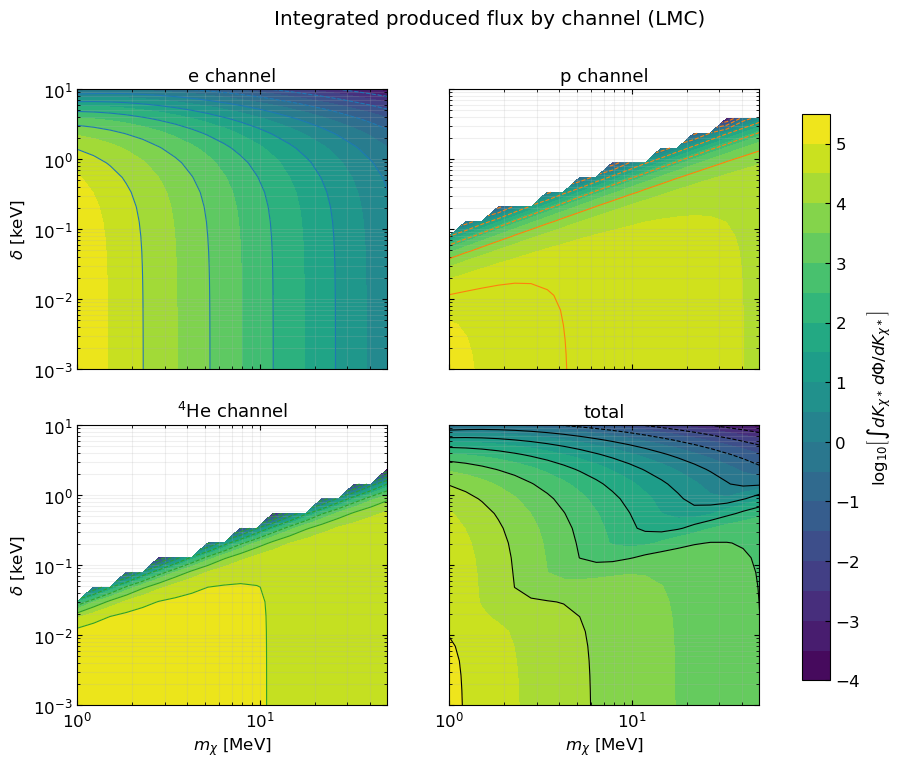

In [36]:
# 2x2 map of integrated produced flux: e, p, He, total

maps = [
    (PHI_E_MAP,  "e channel", TARGETS["e"]["color"]),
    (PHI_P_MAP,  "p channel", TARGETS["p"]["color"]),
    (PHI_HE_MAP, r"$^4$He channel", TARGETS["He"]["color"]),
    (PHI_TOT_MAP, "total", "black"),
]

fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.0), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (Z, title, color) in zip(axes, maps):
    Zplot = np.where(Z > 0.0, np.log10(Z), np.nan)
    cf = ax.contourf(MCHI_GRID_MEV, DELTA_GRID_KEV, Zplot, levels=20)
    ax.contour(MCHI_GRID_MEV, DELTA_GRID_KEV, Zplot, levels=8, colors=color, linewidths=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.grid(alpha=0.20, which="both")

for ax in axes[2:]:
    ax.set_xlabel(r"$m_\chi\ [{\rm MeV}]$")
for ax in axes[::2]:
    ax.set_ylabel(r"$\delta\ [{\rm keV}]$")

cbar = fig.colorbar(cf, ax=axes, shrink=0.92)
cbar.set_label(r"$\log_{10}\!\left[\int dK_{\chi^\ast}\, d\Phi/dK_{\chi^\ast}\right]$")

fig.suptitle(f"Integrated produced flux by channel ({HALO_FOR_CHANNEL_MAPS})")
plt.show()

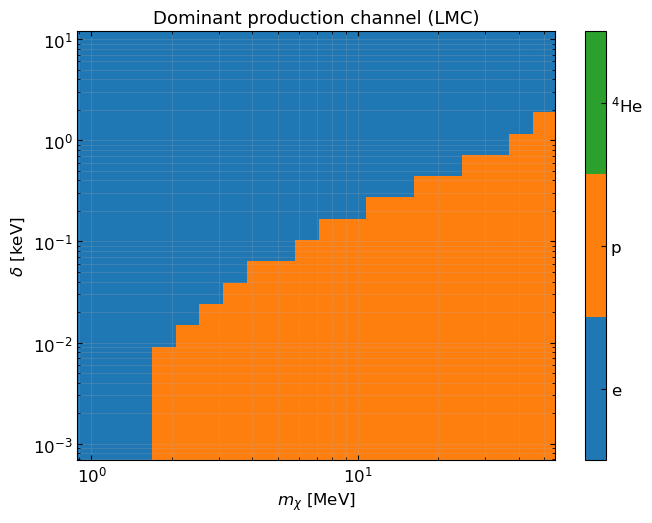

In [37]:
# Dominant-channel map

STACK = np.stack([PHI_E_MAP, PHI_P_MAP, PHI_HE_MAP], axis=0)
dominant = np.argmax(STACK, axis=0)

# Mask regions where the total flux is negligible
mask_low = PHI_TOT_MAP <= 0.0
dominant_masked = np.ma.array(dominant, mask=mask_low)

from matplotlib.colors import ListedColormap
cmap = ListedColormap([TARGETS["e"]["color"], TARGETS["p"]["color"], TARGETS["He"]["color"]])

fig, ax = plt.subplots(figsize=(7.0, 5.4))
pcm = ax.pcolormesh(
    MCHI_GRID_MEV,
    DELTA_GRID_KEV,
    dominant_masked,
    shading="auto",
    cmap=cmap,
    vmin=-0.5,
    vmax=2.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_\chi\ [{\rm MeV}]$")
ax.set_ylabel(r"$\delta\ [{\rm keV}]$")
ax.set_title(f"Dominant production channel ({HALO_FOR_CHANNEL_MAPS})")
ax.grid(alpha=0.20, which="both")

cbar = fig.colorbar(pcm, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["e", "p", r"$^4$He"])

plt.tight_layout()
plt.show()

In [38]:
# Save channel-comparison results

SOLAR_IDM_CHANNEL_RESULTS = {
    "benchmark": {
        "K_keV": K_CHANNEL_KEV,
        "spectra_shm": spectra_shm,
        "spectra_lmc": spectra_lmc,
    },
    "maps": {
        "halo": HALO_FOR_CHANNEL_MAPS,
        "mchi_grid_MeV": MCHI_GRID_MEV,
        "delta_grid_keV": DELTA_GRID_KEV,
        "phi_e": PHI_E_MAP,
        "phi_p": PHI_P_MAP,
        "phi_he": PHI_HE_MAP,
        "phi_total": PHI_TOT_MAP,
    }
}